In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import scipy

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [2]:
LOGG_SUN = 4.437

tyler_cols = ["source_id", "Teff", "e_Teff_lower", "e_Teff_upper",
              "Logg", "Mass", "e_Mass_lower", "e_Mass_upper",
              "cool_age", "e_cool_age_lower", "e_cool_age_upper",
              "tot_age", "tot_age_error_lower", "tot_age_error_upper",
              "spectype", "ruwe", "phot_bp_rp_excess_factor", "R_chance_align"]
tyler = pd.read_csv("../data/tyler/tyler_wdms.csv", usecols=tyler_cols)
tyler.rename({"phot_bp_rp_excess_factor": "bp_rp_excess"}, axis=1, inplace=True)

def prep_tyler(data, tyler):
    """Merge tyler WD fits onto a wide-binary dataframe and compute derived columns."""
    data = pd.merge(data, tyler, left_on="wd_source_id", right_on="source_id", how="inner")

    data["mass_best"]   = data["Mass"]
    data["teff_best"]   = data["Teff"]
    data["radius_best"] = np.sqrt(data["Mass"] * 10**(LOGG_SUN - data["Logg"]))

    # Ages in Gyr (Tyler already provides them in Gyr)
    data["wd_age"]         = data["tot_age"]
    data["wd_age_lo"]      = data["tot_age_error_lower"]
    data["wd_age_hi"]      = data["tot_age_error_upper"]
    data["wd_cool_age"]    = data["cool_age"]
    data["wd_cool_age_lo"] = data["e_cool_age_lower"]
    data["wd_cool_age_hi"] = data["e_cool_age_upper"]
    return data

In [3]:
data1 = pd.read_csv("../data/merge/apogee_ngf21_merged.csv")
data2 = pd.read_csv("../data/merge/astra_ngf21_merged.csv")
data3 = pd.read_csv("../data/merge/galah_ngf21_merged.csv")

data_apogee = prep_tyler(
    data1.query("FE_H > -999 & ALPHA_M_ERR < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1"),
    tyler)
data_astra = prep_tyler(
    data2.query("fe_h > -999 & flag_bad == False & e_alpha_m_atm < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1"),
    tyler)
data_galah = prep_tyler(
    data3.query("e_fe_h < 0.1 & e_Mg_fe < 0.1 & wd_phot_bp_rp_excess_factor < 1.2 & wd_ruwe < 1.2 & R_chance_align < 0.1"),
    tyler)

In [4]:
# Remove duplicates across surveys (prefer astra, then apogee, then galah)
mm1 = ~data_apogee.wd_source_id.isin(data_astra.wd_source_id)
data_apogee = data_apogee[mm1]

mm2 = np.all([~data_galah.wd_source_id.isin(data_astra.wd_source_id),
              ~data_galah.wd_source_id.isin(data_apogee.wd_source_id)], axis=0)
data_galah = data_galah[mm2]

print(len(data_galah), len(data_astra) + len(data_apogee))

18 259


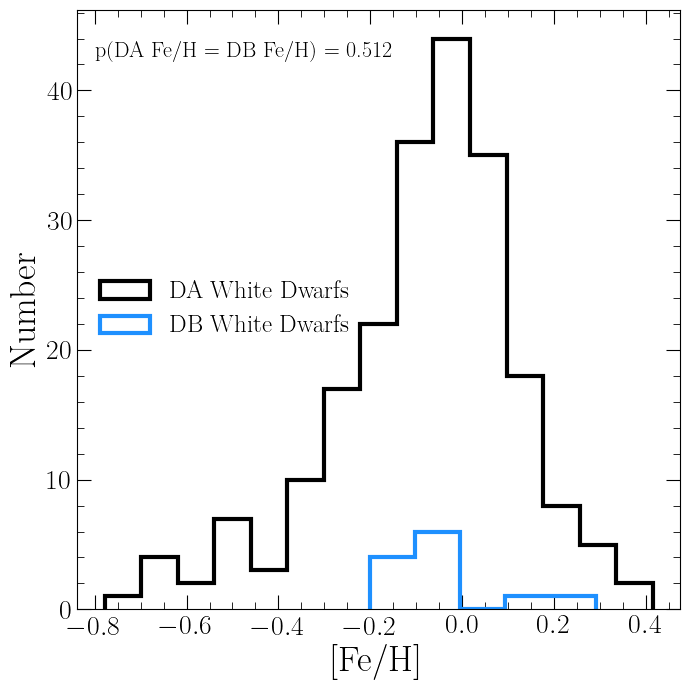

In [5]:
fig, ax = plt.subplots(ncols=1)

is_da_ap = data_apogee["spectype"].str.startswith("DA")
is_da_as = data_astra["spectype"].str.startswith("DA")
is_db_ap = data_apogee["spectype"].str.startswith("DB")
is_db_as = data_astra["spectype"].str.startswith("DB")

feh_all = np.append(data_apogee.loc[is_da_ap, "FE_H"],
                    data_astra.loc[is_da_as, "fe_h"])
feh_all = feh_all[~np.isnan(feh_all)]

feh_dbs = np.append(data_apogee.loc[is_db_ap, "FE_H"],
                    data_astra.loc[is_db_as, "fe_h"])
feh_dbs = feh_dbs[~np.isnan(feh_dbs)]

ks_equal = scipy.stats.ks_2samp(feh_all, feh_dbs, alternative="two-sided", method='asymp')

ax.hist(feh_all, histtype="step", linewidth=3, color="k", label="DA White Dwarfs")
ax.hist(feh_dbs, histtype="step", linewidth=3, color="dodgerblue", label="DB White Dwarfs")
ax.set_xlabel("[Fe/H]"); ax.set_ylabel("Number")
ax.legend(framealpha=0)
ax.text(0.03, 0.95,
    rf"p(DA Fe/H $=$ DB Fe/H) = {ks_equal.pvalue:1.3f}",
    ha="left", va="top", fontsize=16, transform=ax.transAxes)
fig.tight_layout()
fig.savefig("figures/massloss_metallicity_tyler.pdf")

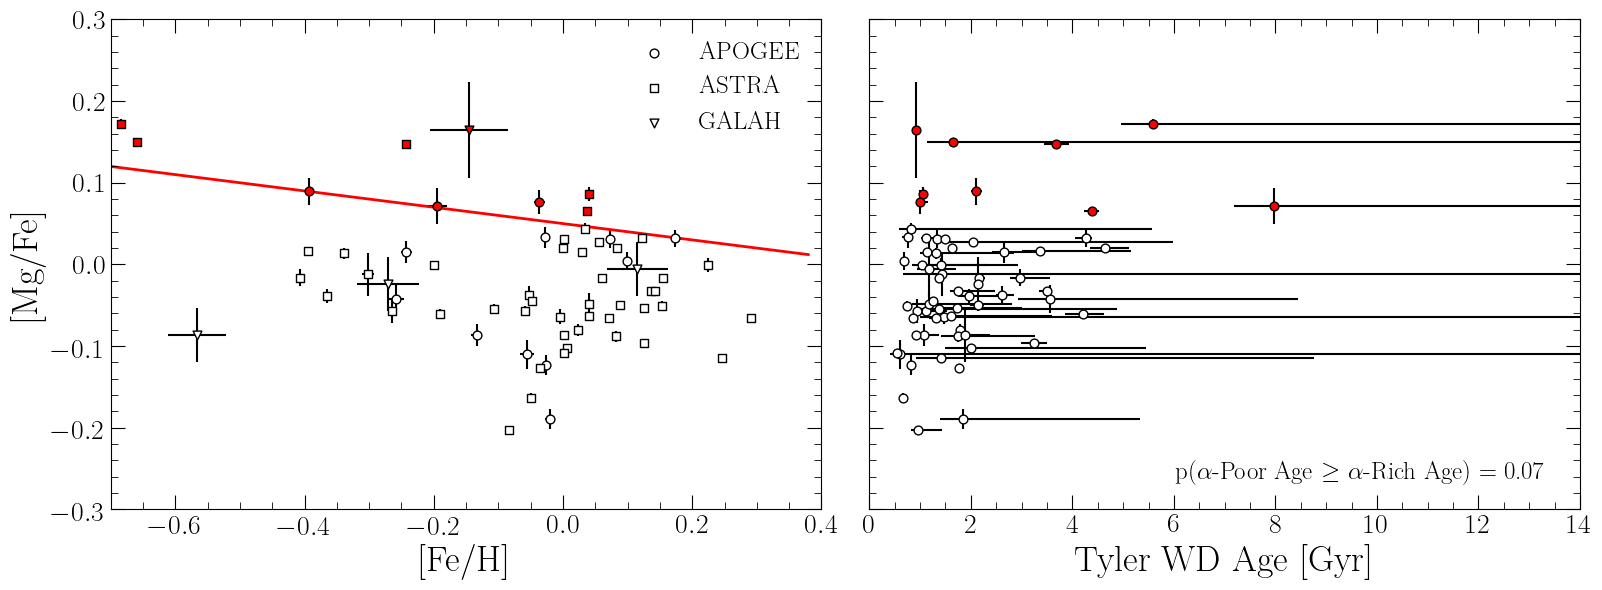

In [6]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)

# ── APOGEE ──────────────────────────────────────────────────────────────
df_ap = data_apogee.query("mass_best > 0.63").copy()
df_ap.loc[:, "mg_fe"] = df_ap["MG_FE"]
df_ap.loc[:, "e_mg_fe"] = df_ap["MG_FE_ERR"]
mask_ap = (-0.1 * df_ap["FE_H"] + 0.05) < df_ap["mg_fe"]

ax[0].errorbar(df_ap["FE_H"], df_ap["mg_fe"],
               xerr=df_ap["FE_H_ERR"], yerr=df_ap["e_mg_fe"], c="k", fmt="None", zorder=0)
ax[0].scatter(df_ap.loc[~mask_ap, "FE_H"], df_ap.loc[~mask_ap, "mg_fe"],
              c="white", edgecolor="k", zorder=1, label="APOGEE", s=40)
ax[0].scatter(df_ap.loc[mask_ap, "FE_H"], df_ap.loc[mask_ap, "mg_fe"],
              c="red", edgecolor="k", zorder=2, s=40)

# ── ASTRA ───────────────────────────────────────────────────────────────
df_as = data_astra.copy()
df_as.loc[:, "mg_fe"] = df_as["mg_h"] - df_as["fe_h"]
df_as.loc[:, "e_mg_fe"] = np.sqrt(df_as["e_mg_h"]**2 + df_as["e_fe_h"]**2)
df_as = df_as.query("mass_best > 0.63").copy()
mask_as = (-0.1 * df_as["fe_h"] + 0.05) < df_as["mg_fe"]

ax[0].errorbar(df_as["fe_h"], df_as["mg_fe"],
               xerr=df_as["e_fe_h"], yerr=df_as["e_mg_fe"], c="k", fmt="None", zorder=0)
ax[0].scatter(df_as.loc[~mask_as, "fe_h"], df_as.loc[~mask_as, "mg_fe"],
              c="white", edgecolor="k", zorder=1, marker="s", label="ASTRA", s=40)
ax[0].scatter(df_as.loc[mask_as, "fe_h"], df_as.loc[mask_as, "mg_fe"],
              c="red", edgecolor="k", zorder=2, s=40, marker="s")

# ── GALAH ───────────────────────────────────────────────────────────────
df_ga = data_galah.copy()
df_ga = df_ga.query("mass_best > 0.63").copy()
mask_ga = (-0.1 * df_ga["fe_h"] + 0.05) < df_ga["Mg_fe"]

ax[0].errorbar(df_ga["fe_h"], df_ga["Mg_fe"],
               xerr=df_ga["e_fe_h"], yerr=df_ga["e_Mg_fe"], c="k", fmt="None", zorder=0)
ax[0].scatter(df_ga.loc[~mask_ga, "fe_h"], df_ga.loc[~mask_ga, "Mg_fe"],
              c="white", edgecolor="k", zorder=1, marker="v", label="GALAH", s=40)
ax[0].scatter(df_ga.loc[mask_ga, "fe_h"], df_ga.loc[mask_ga, "Mg_fe"],
              c="red", edgecolor="k", zorder=2, s=40, marker="v")

xx = np.array(ax[0].get_xlim())
ax[0].plot(xx, -0.1 * xx + 0.05, c="red", lw=2, zorder=0)
ax[0].set_xlim(xx)
ax[0].set_ylim(-0.3, 0.3); ax[0].set_xlim(-0.7, 0.4)
ax[0].set_xlabel("[Fe/H]"); ax[0].set_ylabel("[Mg/Fe]")
ax[0].legend(framealpha=0)

# ── AGE vs [Mg/Fe] ──────────────────────────────────────────────────────
age_hi = np.concatenate((
    df_ap.loc[mask_ap, ["wd_age", "mg_fe"]].to_numpy(),
    df_as.loc[mask_as, ["wd_age", "mg_fe"]].to_numpy(),
    df_ga.loc[mask_ga, ["wd_age", "Mg_fe"]].to_numpy(),
))
e_age_hi = np.concatenate((
    df_ap.loc[mask_ap, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    df_as.loc[mask_as, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    df_ga.loc[mask_ga, ["wd_age_lo", "wd_age_hi", "e_Mg_fe"]].to_numpy(),
))
age_lo = np.concatenate((
    df_ap.loc[~mask_ap, ["wd_age", "mg_fe"]].to_numpy(),
    df_as.loc[~mask_as, ["wd_age", "mg_fe"]].to_numpy(),
    df_ga.loc[~mask_ga, ["wd_age", "Mg_fe"]].to_numpy(),
))
e_age_lo = np.concatenate((
    df_ap.loc[~mask_ap, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    df_as.loc[~mask_as, ["wd_age_lo", "wd_age_hi", "e_mg_fe"]].to_numpy(),
    df_ga.loc[~mask_ga, ["wd_age_lo", "wd_age_hi", "e_Mg_fe"]].to_numpy(),
))

ax[1].errorbar(age_hi[:,0], age_hi[:,1], xerr=e_age_hi[:,:2].T, yerr=e_age_hi[:,2],
               fmt="none", c="k", zorder=0)
ax[1].scatter(age_hi[:,0], age_hi[:,1], c="red", edgecolor="k", zorder=1, s=40)

ax[1].errorbar(age_lo[:,0], age_lo[:,1], xerr=e_age_lo[:,:2].T, yerr=e_age_lo[:,2],
               fmt="none", c="k", zorder=0)
ax[1].scatter(age_lo[:,0], age_lo[:,1], c="white", edgecolor="k", zorder=1, s=40)

ks_equal = scipy.stats.ks_2samp(age_hi[:,0], age_lo[:,0], alternative="less", method='asymp')
ax[1].text(0.95, 0.1,
    rf"p($\alpha$-Poor Age $\geq$ $\alpha$-Rich Age) = {ks_equal.pvalue:1.2f}",
    ha="right", va="top", fontsize=18, transform=ax[1].transAxes)

ax[1].set_xlabel("Tyler WD Age [Gyr]")
ax[1].set_xlim(0, 14)

fig.tight_layout()
fig.savefig("figures/metallicity_age_tyler.pdf")